In [ ]:
# Local setup
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "datasets/data.csv"
MODEL_DIR = PROJECT_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_PATH:", DATA_PATH)
print("MODEL_DIR:", MODEL_DIR)

PROJECT_DIR: d:\UIT\Sem6\DS102\Student_Dropout_Risk_Prediction
DATA_PATH: d:\UIT\Sem6\DS102\Student_Dropout_Risk_Prediction\data.csv
MODEL_DIR: d:\UIT\Sem6\DS102\Student_Dropout_Risk_Prediction\models


In [2]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import clone
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Imbalance handling
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

# LightGBM
from lightgbm import LGBMClassifier

# XGBoost
from xgboost import XGBClassifier

# Save model
import joblib
import time

In [3]:
# Load and inspect the dataset
df = pd.read_csv(DATA_PATH, sep=";")

# Student Dropout Risk Prediction

## Project objective

Notebook này xây dựng một **binary classification model** để dự đoán liệu một sinh viên có nguy cơ **Dropout** hay không.

Dataset gốc có ba class: `Dropout`, `Enrolled`, và `Graduate`. Trong bài này, task được chuyển thành **binary dropout-risk prediction** bằng cách loại bỏ class `Enrolled`, vì nhóm sinh viên này chưa có final academic outcome rõ ràng.

Sau khi chọn model, notebook sẽ lưu một **final checkpoint** để dùng cho demo app.

# **DATA UNDERSTANDING**

In [4]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
# Display the number of rows and columns
print(f"- Số dòng: {df.shape[0]}")
print(f"- Số cột: {df.shape[1]}")

- Số dòng: 4424
- Số cột: 37


In [6]:
# Display dataset attributes
print("- Thuộc tính của dữ liệu:")
for col in df.columns:
    print(f"{col}.")

- Thuộc tính của dữ liệu:
Marital status.
Application mode.
Application order.
Course.
Daytime/evening attendance	.
Previous qualification.
Previous qualification (grade).
Nacionality.
Mother's qualification.
Father's qualification.
Mother's occupation.
Father's occupation.
Admission grade.
Displaced.
Educational special needs.
Debtor.
Tuition fees up to date.
Gender.
Scholarship holder.
Age at enrollment.
International.
Curricular units 1st sem (credited).
Curricular units 1st sem (enrolled).
Curricular units 1st sem (evaluations).
Curricular units 1st sem (approved).
Curricular units 1st sem (grade).
Curricular units 1st sem (without evaluations).
Curricular units 2nd sem (credited).
Curricular units 2nd sem (enrolled).
Curricular units 2nd sem (evaluations).
Curricular units 2nd sem (approved).
Curricular units 2nd sem (grade).
Curricular units 2nd sem (without evaluations).
Unemployment rate.
Inflation rate.
GDP.
Target.


In [7]:
# Display feature data types
print("- Kiểu dữ liệu của thuộc tính:")
print(df.info())

- Kiểu dữ liệu của thuộc tính:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's q

In [8]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

print(numeric_cols)

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [9]:
# Summary statistics for numeric columns
print("- Thống kê dữ liệu:")
df.describe()

- Thống kê dữ liệu:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


C:\Users\duong\AppData\Roaming\Python\Python313\site-packages\seaborn\utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\duong\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


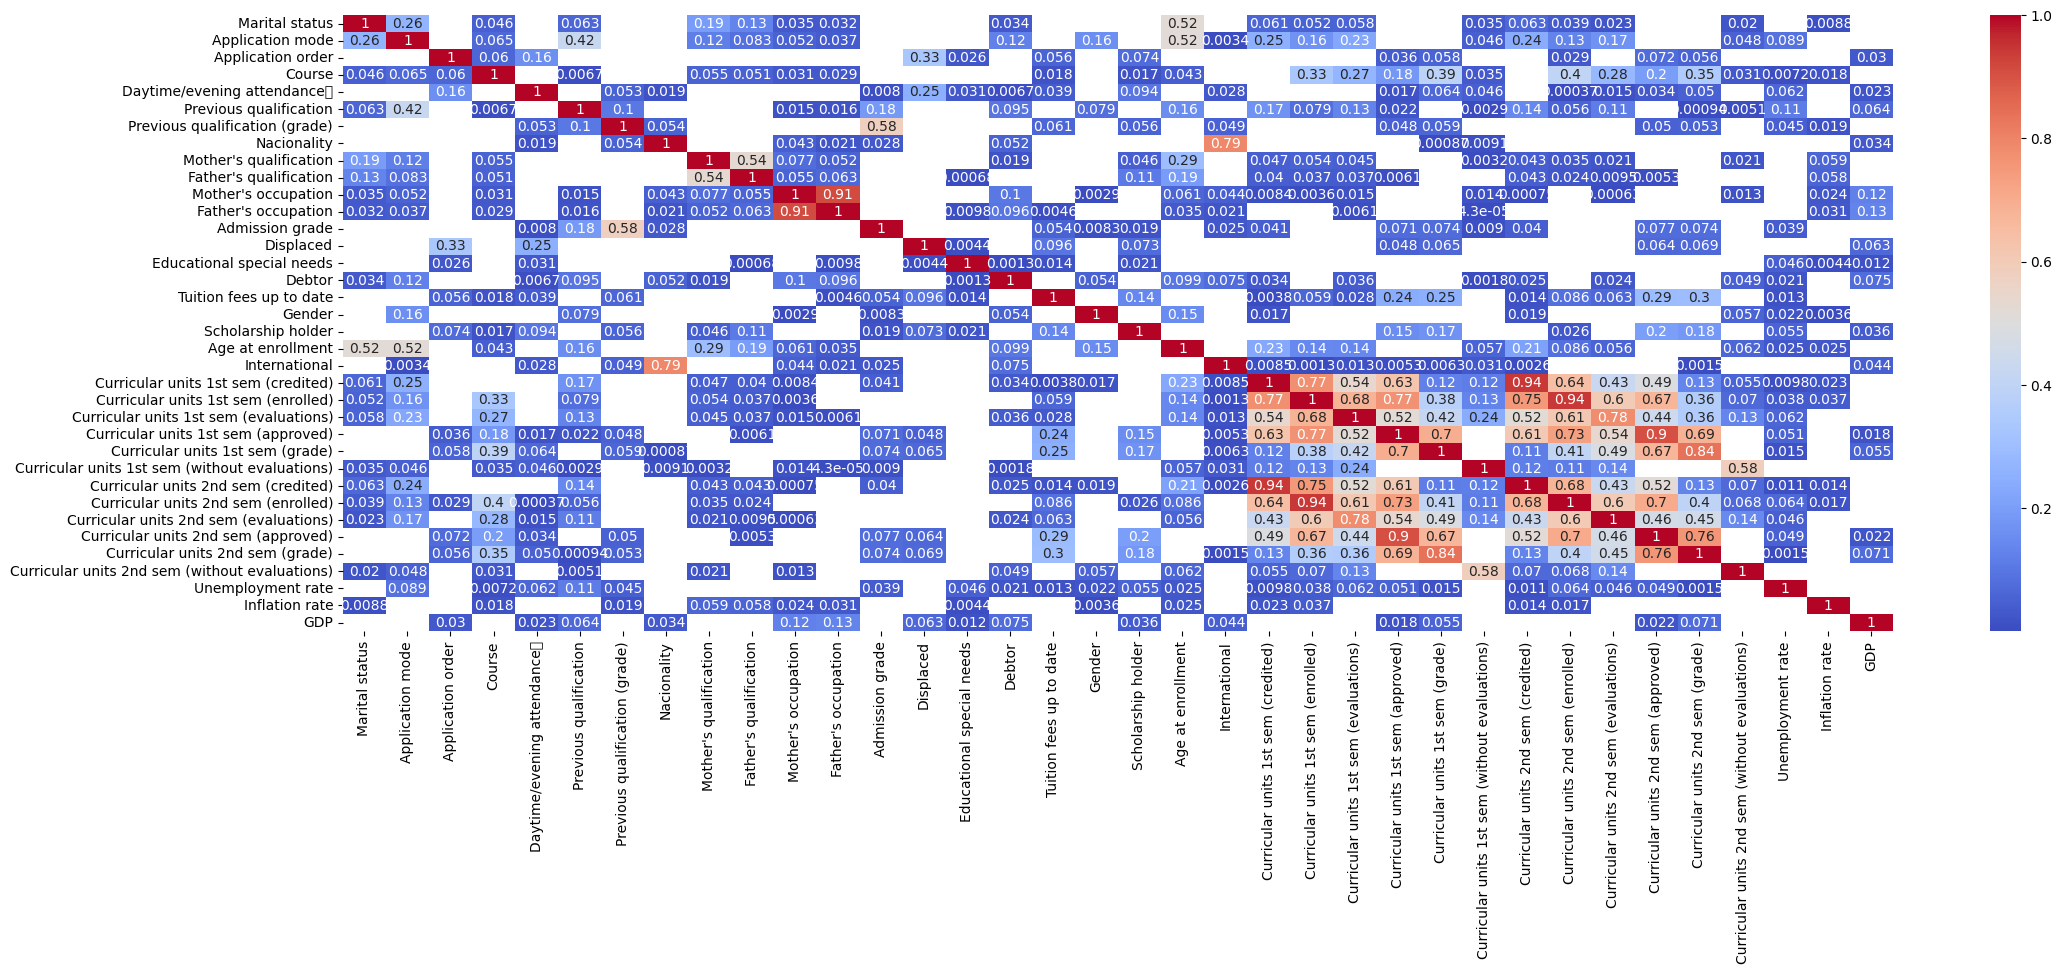

In [10]:
# Correlation matrix
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

positive_corr = corr_matrix[corr_matrix > 0]

plt.figure(figsize=(25, 8))
sns.heatmap(positive_corr, annot=True, cmap='coolwarm')

plt.show()

In [11]:
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    print(f"\n- {col}")
    print(df[col].value_counts())


- Target
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


# **DATA VISUALIZATION**

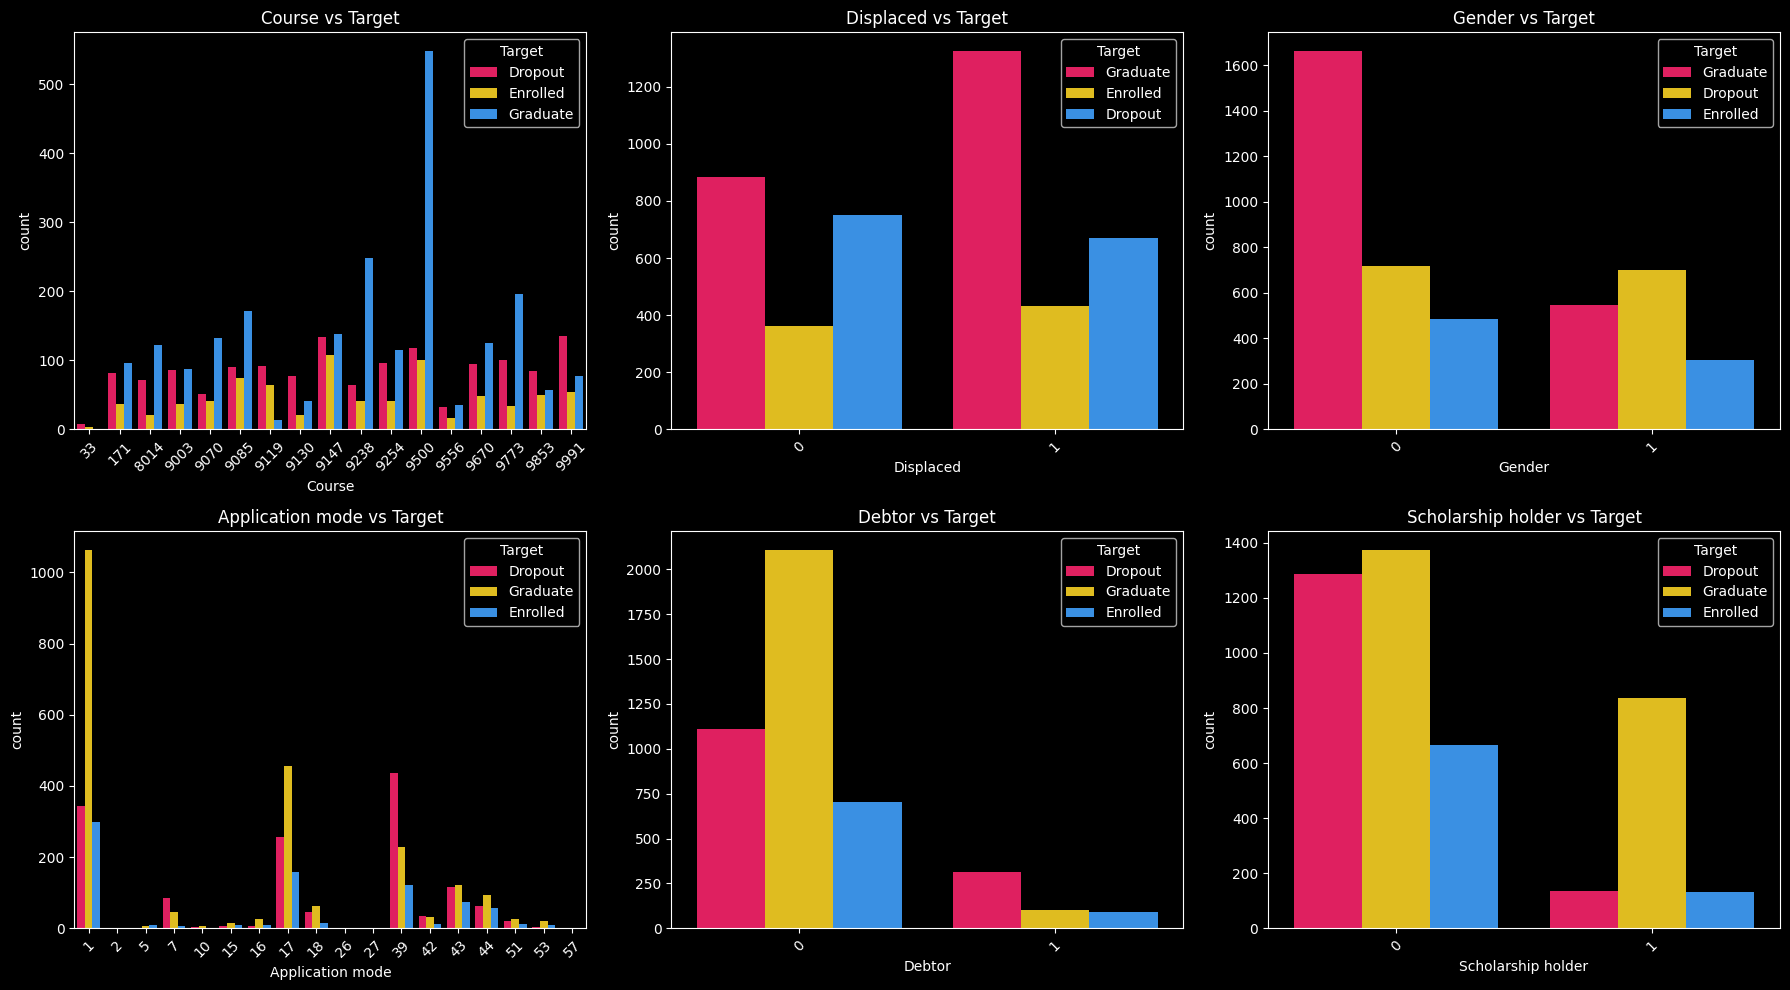

In [12]:
categorical_features = [
    'Course',
    'Displaced',
    'Gender',
    'Application mode',
    'Debtor',
    'Scholarship holder'
]

plt.style.use('dark_background')
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

custom_colors = ['#ff0055', '#ffd000', '#1e90ff']

for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        hue='Target',
        ax=axes[i],
        palette=custom_colors
    )

    axes[i].set_title(f'{feature} vs Target')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

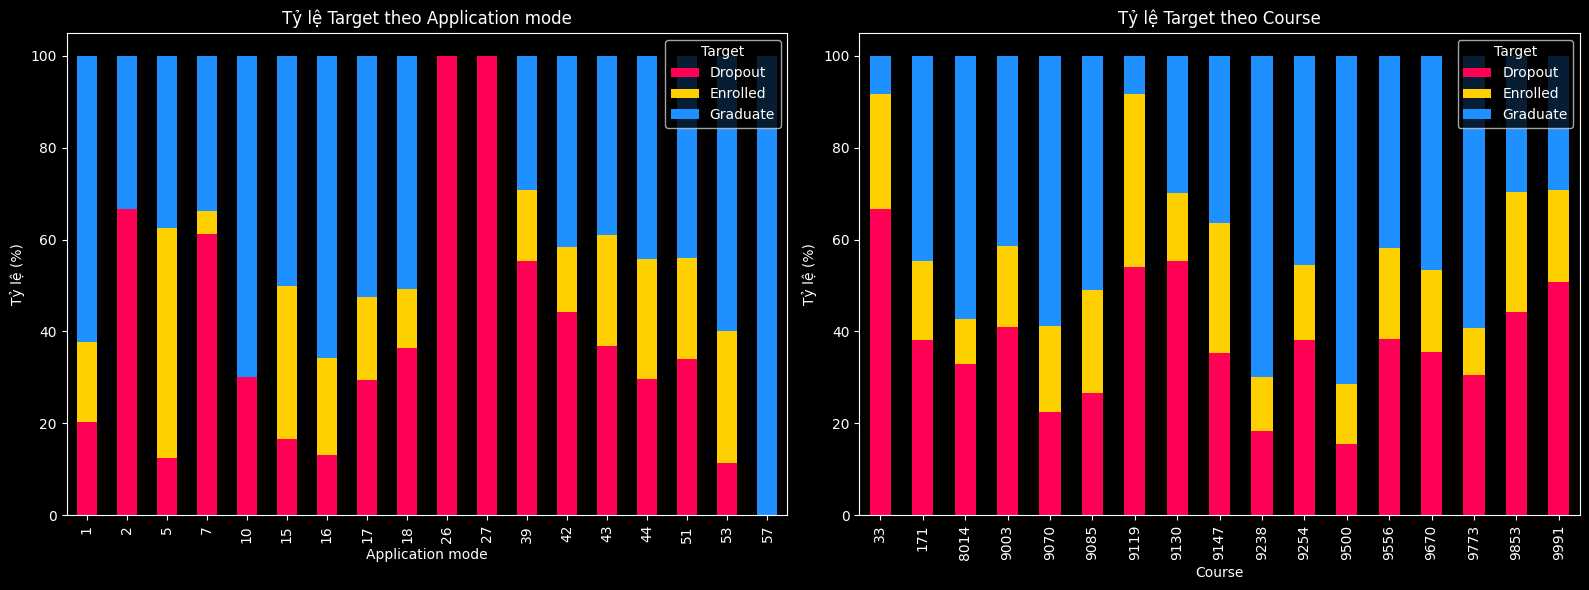

In [13]:
plt.style.use('dark_background')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

app_target = pd.crosstab(
    df['Application mode'],
    df['Target'],
    normalize='index'
) * 100

app_target.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    color=['#ff0055', '#ffd000', '#1e90ff']
)

axes[0].set_title('Tỷ lệ Target theo Application mode')
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].legend(title='Target')

course_target = pd.crosstab(
    df['Course'],
    df['Target'],
    normalize='index'
) * 100

course_target.plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#ff0055', '#ffd000', '#1e90ff']
)

axes[1].set_title('Tỷ lệ Target theo Course')
axes[1].set_ylabel('Tỷ lệ (%)')
axes[1].legend(title='Target')

plt.tight_layout()

plt.show()

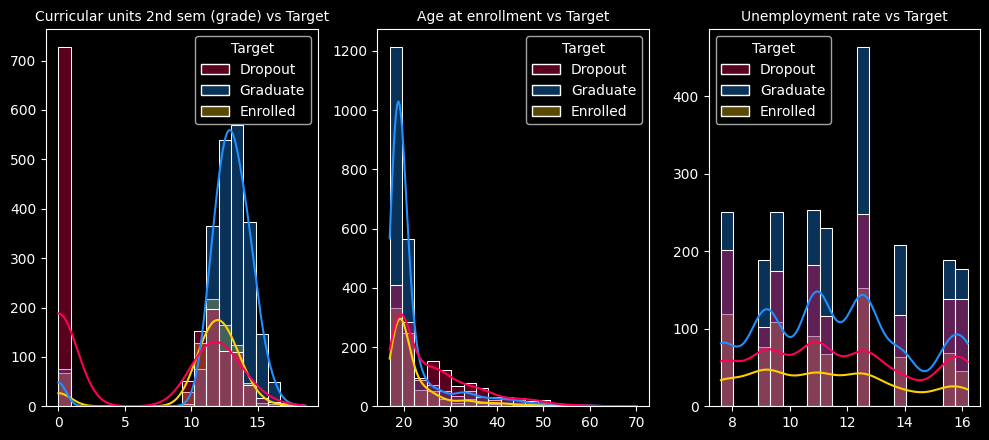

In [14]:
features = [
    'Curricular units 2nd sem (grade)',
    'Age at enrollment',
    'Unemployment rate'
]
target_colors = {
    'Dropout': '#ff0055',
    'Enrolled': '#ffd000',
    'Graduate': '#1e90ff'
}
target_col = 'Target'

plt.style.use("dark_background")

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.patch.set_facecolor("black")

for ax, col in zip(axes, features):

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        kde=True,
        palette=target_colors,
        alpha=0.35,
        bins=20,
        ax=ax
    )

    ax.set_title(f'{col} vs Target', fontsize=10, color='white')
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_edgecolor("white")

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

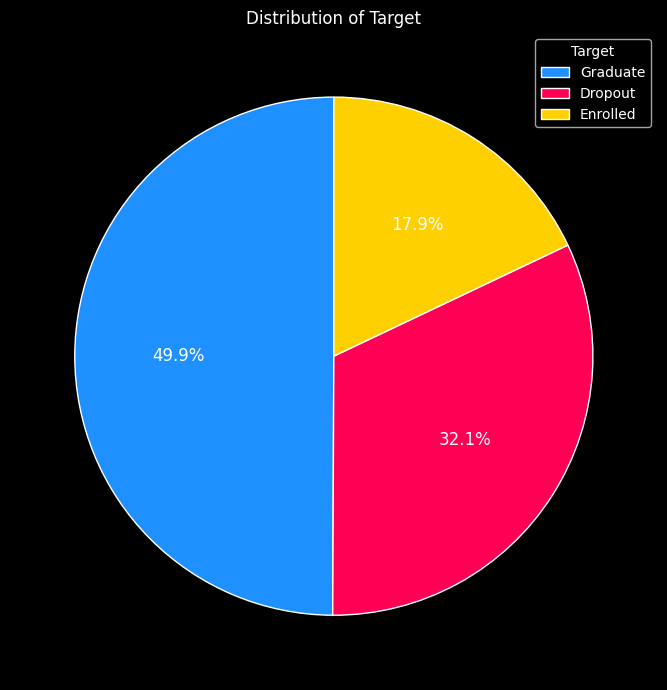

In [15]:
# Analyze the target variable
target_counts = df['Target'].value_counts()

target_colors = {
    'Graduate': '#1e90ff',
    'Dropout': '#ff0055',
    'Enrolled': '#ffd000',
}

colors = [target_colors[i] for i in target_counts.index]

plt.figure(figsize=(7,7), facecolor='black')

wedges, texts, autotexts = plt.pie(
    x=target_counts.values,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    textprops={'color': 'white', 'fontsize': 12}
)

plt.legend(
    wedges,
    target_counts.index,
    title="Target",
    loc="best",
    facecolor='black',
    labelcolor='white'
)

plt.title('Distribution of Target')

plt.tight_layout()
plt.show()


# **DATA BALANCE ASSESSMENT**

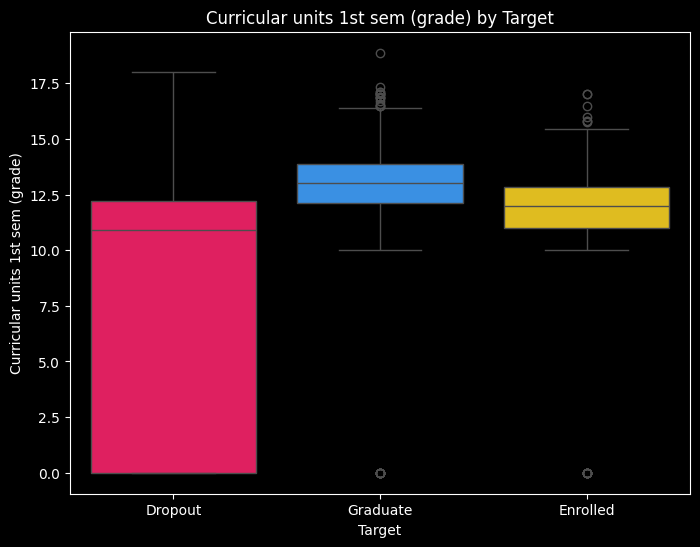

In [16]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Target',
    y='Curricular units 1st sem (grade)',
    hue='Target',
    data=df,
    palette=target_colors,
    legend=False
)

plt.title('Curricular units 1st sem (grade) by Target')
plt.xlabel('Target')
plt.ylabel('Curricular units 1st sem (grade)')

plt.show()

# **DATA PREPROCESSING**

In [17]:
# Remove the Enrolled class
df = df[df["Target"] != "Enrolled"].copy()

Dataset gốc có ba target classes: `Dropout`, `Enrolled`, và `Graduate`.

Trong notebook này, task được reformulate thành **binary dropout-risk prediction**. Class `Enrolled` được loại bỏ vì các sinh viên này chưa có final outcome rõ ràng. Sau bước này, target chỉ còn:

- `Graduate = 0`
- `Dropout = 1`

Như vậy, `Dropout` là positive class khi tính Precision, Recall, và F1-score.

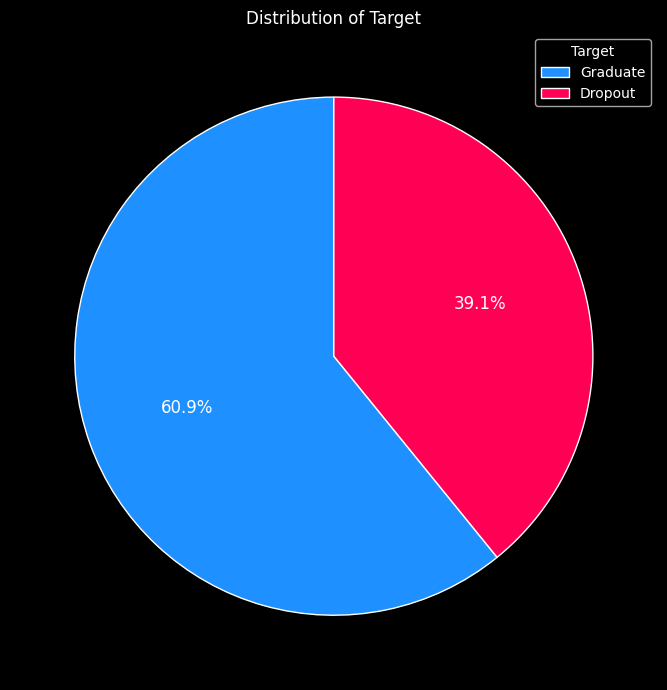

In [18]:
target_counts = df['Target'].value_counts()

target_colors = {
    'Graduate': '#1e90ff',
    'Dropout': '#ff0055',
}

colors = [target_colors[i] for i in target_counts.index]

plt.figure(figsize=(7,7), facecolor='black')

wedges, texts, autotexts = plt.pie(
    x=target_counts.values,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    textprops={'color': 'white', 'fontsize': 12}
)

plt.legend(
    wedges,
    target_counts.index,
    title="Target",
    loc="best",
    facecolor='black',
    labelcolor='white'
)

plt.title('Distribution of Target')

plt.tight_layout()
plt.show()

**1. Handling missing values**

In [19]:
print("Kiểm tra giá trị thiếu:")
print(df.isnull().sum())

Kiểm tra giá trị thiếu:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                      

**2. Duplicate records detection**

In [20]:
print(f"Kiểm tra số dòng trùng lặp: {df.duplicated().sum()} dòng.")

Kiểm tra số dòng trùng lặp: 0 dòng.


**3. Renaming inconsistent column names**

In [21]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

**4. Defining categorical and binary feature groups**

In [22]:
categorical_cols = [
    "marital_status",
    "application_mode",
    "course",
    "daytime/evening_attendance",
    "previous_qualification",
    "nacionality",
    "mother's_qualification",
    "father's_qualification",
    "mother's_occupation",
    "father's_occupation"
]

binary_cols = [
    "displaced",
    "educational_special_needs",
    "debtor",
    "tuition_fees_up_to_date",
    "gender",
    "scholarship_holder",
    "international"
]

# **FEATURE ENGINEERING**

Phần này tạo thêm các student-level features từ các columns sẵn có.

Các engineered features được tính **row by row**, ví dụ approval rates, grade change, và financial risk. Vì các phép tính này không dùng target hoặc thống kê toàn dataset nên không gây leakage nghiêm trọng.

**1. Encoding the target variable**

Binary target được encode như sau:

- `Graduate = 0`
- `Dropout = 1`

Cách encode này giúp `Dropout` trở thành positive class, nên các metrics như Precision, Recall, và F1-score được diễn giải theo hướng phát hiện sinh viên có nguy cơ dropout.

In [23]:
# Encode Dropout as 1 and Graduate as 0
df["target"] = df["target"].apply(lambda x: 1 if x == "Dropout" else 0)

## Feature Engineering

Ở bước này, ta tạo thêm một số **engineered features** để model học tốt hơn về academic progress, grade performance và financial risk.

- `approval_rate_1st_sem = curricular_units_1st_sem_(approved) / curricular_units_1st_sem_(enrolled)`

- `approval_rate_2nd_sem = curricular_units_2nd_sem_(approved) / curricular_units_2nd_sem_(enrolled)`

- `total_approved_units = curricular_units_1st_sem_(approved) + curricular_units_2nd_sem_(approved)`

- `total_enrolled_units = curricular_units_1st_sem_(enrolled) + curricular_units_2nd_sem_(enrolled)`

- `overall_approval_rate = total_approved_units / total_enrolled_units`

- `grade_change = curricular_units_2nd_sem_(grade) - curricular_units_1st_sem_(grade)`

- `avg_semester_grade = (curricular_units_1st_sem_(grade) + curricular_units_2nd_sem_(grade)) / 2`

- `financial_risk = debtor + (1 - tuition_fees_up_to_date)`

In [24]:
# Feature engineering

def add_engineered_features(dataframe):
    dataframe = dataframe.copy()
    eps = 1e-6

    dataframe["approval_rate_1st_sem"] = (
        dataframe["curricular_units_1st_sem_(approved)"] /
        (dataframe["curricular_units_1st_sem_(enrolled)"] + eps)
    )

    dataframe["approval_rate_2nd_sem"] = (
        dataframe["curricular_units_2nd_sem_(approved)"] /
        (dataframe["curricular_units_2nd_sem_(enrolled)"] + eps)
    )

    dataframe["total_approved_units"] = (
        dataframe["curricular_units_1st_sem_(approved)"] +
        dataframe["curricular_units_2nd_sem_(approved)"]
    )

    dataframe["total_enrolled_units"] = (
        dataframe["curricular_units_1st_sem_(enrolled)"] +
        dataframe["curricular_units_2nd_sem_(enrolled)"]
    )

    dataframe["overall_approval_rate"] = (
        dataframe["total_approved_units"] /
        (dataframe["total_enrolled_units"] + eps)
    )

    dataframe["grade_change"] = (
        dataframe["curricular_units_2nd_sem_(grade)"] -
        dataframe["curricular_units_1st_sem_(grade)"]
    )

    dataframe["avg_semester_grade"] = (
        dataframe["curricular_units_1st_sem_(grade)"] +
        dataframe["curricular_units_2nd_sem_(grade)"]
    ) / 2

    dataframe["financial_risk"] = (
        dataframe["debtor"].astype(int) +
        (1 - dataframe["tuition_fees_up_to_date"].astype(int))
    )

    return dataframe

In [25]:
# Prepare X, y

X = df.drop("target", axis=1)
y = df["target"]

# Save original input columns before feature engineering
base_input_columns = list(X.columns)

# Apply feature engineering
X = add_engineered_features(X)

engineered_feature_names = [
    col for col in X.columns
    if col not in base_input_columns
]

print("Original features:", len(base_input_columns))
print("Engineered features:", engineered_feature_names)
print("Total features after feature extraction:", X.shape[1])

Original features: 36
Engineered features: ['approval_rate_1st_sem', 'approval_rate_2nd_sem', 'total_approved_units', 'total_enrolled_units', 'overall_approval_rate', 'grade_change', 'avg_semester_grade', 'financial_risk']
Total features after feature extraction: 44


**2. Train / validation / test split**

Dataset được chia thành ba phần:

- 60% **training set** để fit models,
- 20% **validation set** để chọn model và tuning,
- 20% **test set** để final evaluation.

Test set được giữ riêng và chỉ dùng đúng một lần sau khi toàn bộ model selection và hyperparameter tuning đã hoàn tất.

In [26]:
# Train / Validation / Test split
# Test set is held out and used only for final evaluation

X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

# Validation = 25% of 80% = 20% of the full dataset
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw,
    y_trainval,
    stratify=y_trainval,
    test_size=0.25,
    random_state=42
)

print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:", X_val_raw.shape)
print("X_test_raw:", X_test_raw.shape)

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

X_train_raw: (2178, 44)
X_val_raw: (726, 44)
X_test_raw: (726, 44)

Train distribution:
target
0    0.608356
1    0.391644
Name: proportion, dtype: float64

Validation distribution:
target
0    0.608815
1    0.391185
Name: proportion, dtype: float64

Test distribution:
target
0    0.608815
1    0.391185
Name: proportion, dtype: float64


**3. Feature selection on the training set only**

Feature importance được ước lượng chỉ bằng **training set**.

Điều này giúp tránh dùng thông tin từ validation/test trong bước feature selection. Các features có importance quá thấp sẽ bị loại bỏ để giảm noise và giúp pipeline gọn hơn.

In [27]:
# Feature Selection using training set only

selector_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=4
)

selector_model.fit(X_train_raw, y_train)

importance = pd.DataFrame({
    "Feature": X_train_raw.columns,
    "Importance": selector_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance)

low_importance_cols = importance[
    importance["Importance"] < 0.01
]["Feature"].tolist()

selected_raw_features = [
    col for col in X_train_raw.columns
    if col not in low_importance_cols
]

print("Dropped features:")
print(low_importance_cols)

print("\nSelected raw features:")
print(selected_raw_features)

print("\nNumber of selected raw features:", len(selected_raw_features))

,Feature,Importance
40,overall_approval_rate,0.158773
37,approval_rate_2nd_sem,0.132719
30,curricular_units_2nd_sem_(approved),0.077166
36,approval_rate_1st_sem,0.075445
38,total_approved_units,0.071221
42,avg_semester_grade,0.047894
24,curricular_units_1st_sem_(approved),0.043699
31,curricular_units_2nd_sem_(grade),0.039335
43,financial_risk,0.021896
12,admission_grade,0.021621


Dropped features:
['application_mode', 'application_order', 'curricular_units_1st_sem_(enrolled)', 'total_enrolled_units', 'curricular_units_2nd_sem_(enrolled)', 'debtor', 'gender', 'displaced', 'curricular_units_1st_sem_(credited)', 'curricular_units_2nd_sem_(credited)', 'curricular_units_1st_sem_(without_evaluations)', 'previous_qualification', 'marital_status', 'nacionality', 'curricular_units_2nd_sem_(without_evaluations)', 'daytime/evening_attendance', 'international', 'educational_special_needs']

Selected raw features:
['course', 'previous_qualification_(grade)', "mother's_qualification", "father's_qualification", "mother's_occupation", "father's_occupation", 'admission_grade', 'tuition_fees_up_to_date', 'scholarship_holder', 'age_at_enrollment', 'curricular_units_1st_sem_(evaluations)', 'curricular_units_1st_sem_(approved)', 'curricular_units_1st_sem_(grade)', 'curricular_units_2nd_sem_(evaluations)', 'curricular_units_2nd_sem_(approved)', 'curricular_units_2nd_sem_(grade)', 'u

**4. Apply the selected feature list**

In [28]:
# Keep selected features only

X_train_selected = X_train_raw[selected_raw_features].copy()
X_val_selected = X_val_raw[selected_raw_features].copy()

selected_categorical_cols = [
    col for col in categorical_cols
    if col in selected_raw_features
]

selected_binary_cols = [
    col for col in binary_cols
    if col in selected_raw_features
]

selected_numeric_cols = [
    col for col in selected_raw_features
    if col not in selected_categorical_cols + selected_binary_cols
]

print("Selected categorical columns:", selected_categorical_cols)
print("Selected binary columns:", selected_binary_cols)
print("Selected numeric columns:", selected_numeric_cols)

Selected categorical columns: ['course', "mother's_qualification", "father's_qualification", "mother's_occupation", "father's_occupation"]
Selected binary columns: ['tuition_fees_up_to_date', 'scholarship_holder']
Selected numeric columns: ['previous_qualification_(grade)', 'admission_grade', 'age_at_enrollment', 'curricular_units_1st_sem_(evaluations)', 'curricular_units_1st_sem_(approved)', 'curricular_units_1st_sem_(grade)', 'curricular_units_2nd_sem_(evaluations)', 'curricular_units_2nd_sem_(approved)', 'curricular_units_2nd_sem_(grade)', 'unemployment_rate', 'inflation_rate', 'gdp', 'approval_rate_1st_sem', 'approval_rate_2nd_sem', 'total_approved_units', 'overall_approval_rate', 'grade_change', 'avg_semester_grade', 'financial_risk']


**5. Handle class imbalance using SMOTENC**

**SMOTENC** chỉ được áp dụng trên **training set**.

SMOTENC phù hợp ở đây vì dataset có cả categorical và numerical features. Validation set và test set không được oversample, để evaluation phản ánh phân phối dữ liệu thật hơn.

In [29]:
# Balance training data using SMOTENC
# SMOTENC is applied only to the training set

categorical_for_smote = selected_categorical_cols + selected_binary_cols

categorical_indices = [
    selected_raw_features.index(col)
    for col in categorical_for_smote
]

y_train_before_smote = y_train.copy()

smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_balanced, y_train_balanced = smote_nc.fit_resample(
    X_train_selected,
    y_train
)

X_train_balanced = pd.DataFrame(
    X_train_balanced,
    columns=selected_raw_features
)

for col in selected_raw_features:
    X_train_balanced[col] = pd.to_numeric(X_train_balanced[col])

print("Before SMOTENC on training set:")
print(y_train_before_smote.value_counts())

print("\nAfter SMOTENC on training set:")
print(pd.Series(y_train_balanced).value_counts())

Before SMOTENC on training set:
target
0    1325
1     853
Name: count, dtype: int64

After SMOTENC on training set:
target
0    1325
1    1325
Name: count, dtype: int64


**6. Encoding and scaling**

Preprocessor được fit chỉ trên balanced training data.

- Numeric features được xử lý bằng **StandardScaler**.
- Categorical features được xử lý bằng **OneHotEncoder**.
- Binary features được giữ nguyên bằng passthrough.

Sau đó, preprocessor chỉ transform validation set, không fit lại trên validation.

In [30]:
# Encode categorical features and scale numeric features
# Fit preprocessor only on balanced training set

onehot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), selected_numeric_cols),
        ("cat", onehot_encoder, selected_categorical_cols),
        ("bin", "passthrough", selected_binary_cols)
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train_balanced)
X_val_processed = preprocessor.transform(X_val_selected)

processed_feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names
)

X_val_processed = pd.DataFrame(
    X_val_processed,
    columns=processed_feature_names
)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_val shape:", X_val_processed.shape)
print("Number of processed features:", len(processed_feature_names))

Processed X_train shape: (2650, 152)
Processed X_val shape: (726, 152)
Number of processed features: 152


# **MODEL BUILDING & TRAINING**

Phần này dùng **validation-based model selection pipeline**.

Training set dùng để train candidate models, validation set dùng để so sánh và tuning, còn test set được giữ riêng cho final evaluation. Cách này tránh việc chọn model dựa trên test set.

**1. Train 10 baseline candidate models and evaluate them on the validation set**

Notebook train 10 algorithms khác nhau như baseline candidates.

Mỗi model được fit trên processed training data và evaluate trên validation set. Kết quả baseline dùng để xếp hạng models trước khi chọn top 5 cho hyperparameter tuning.

In [31]:
# Define 10 candidate models
# Model selection is based on validation F1-score, not the test set.

candidate_models = {
    "Logistic Regression": LogisticRegression(
        C=1,
        penalty="l2",
        solver="lbfgs",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=4
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbose=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance"
    ),

    "Naive Bayes": GaussianNB(),

    "Support Vector Machine": SVC(
        kernel="rbf",
        C=10,
        gamma=0.01,
        class_weight="balanced",
        probability=True,
        random_state=42
    )
}

validation_results = []
trained_candidate_models = {}

for model_name, model in candidate_models.items():
    print(f"\nTraining {model_name}...")
    start_time = time.time()

    model.fit(X_train_processed, y_train_balanced)
    y_val_pred = model.predict(X_val_processed)

    training_time = time.time() - start_time

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, zero_division=0),
        "F1-score": f1_score(y_val, y_val_pred, zero_division=0),
        "Training Time (s)": training_time
    }

    validation_results.append(result)
    trained_candidate_models[model_name] = model

    print("Validation results:")
    print(result)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))

    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred, zero_division=0))



Training Logistic Regression...
Validation results:
{'Model': 'Logistic Regression', 'Accuracy': 0.8856749311294766, 'Precision': 0.8551236749116607, 'Recall': 0.852112676056338, 'F1-score': 0.8536155202821869, 'Training Time (s)': 0.03833317756652832}

Confusion Matrix:
[[401  41]
 [ 42 242]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       442
           1       0.86      0.85      0.85       284

    accuracy                           0.89       726
   macro avg       0.88      0.88      0.88       726
weighted avg       0.89      0.89      0.89       726


Training Decision Tree...
Validation results:
{'Model': 'Decision Tree', 'Accuracy': 0.8567493112947658, 'Precision': 0.8237410071942446, 'Recall': 0.8063380281690141, 'F1-score': 0.8149466192170819, 'Training Time (s)': 0.025733232498168945}

Confusion Matrix:
[[393  49]
 [ 55 229]]

Classification Report:
              precision    recall  f1-score

**2. Rank baseline models and select the top 5 models for GridSearchCV**

Các baseline models được rank theo **validation F1-score**.

Chỉ top 5 models được đưa vào **GridSearchCV** để giảm thời gian tuning nhưng vẫn tập trung vào những model có performance tốt nhất ở bước baseline.

In [32]:
# Rank baseline models by validation F1-score and select the top 5 for tuning

baseline_results_df = pd.DataFrame(validation_results)

baseline_results_df = baseline_results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

display(baseline_results_df)

top_5_model_names = baseline_results_df.head(5)["Model"].tolist()
baseline_best_model_name = baseline_results_df.iloc[0]["Model"]

print("Baseline best model on validation set:")
print(baseline_best_model_name)

print("\nTop 5 models selected for GridSearchCV:")
print(top_5_model_names)


,Model,Accuracy,Precision,Recall,F1-score,Training Time (s)
0,XGBoost,0.895317,0.882353,0.845070,0.863309,0.429828
1,LightGBM,0.892562,0.878676,0.841549,0.859712,1.930166
2,Random Forest,0.889807,0.859155,0.859155,0.859155,0.485488
3,Support Vector Machine,0.888430,0.871795,0.838028,0.854578,0.758642
4,Logistic Regression,0.885675,0.855124,0.852113,0.853616,0.038333
5,AdaBoost,0.884298,0.852113,0.852113,0.852113,1.314328
6,Gradient Boosting,0.882920,0.844291,0.859155,0.851658,1.907938
7,Decision Tree,0.856749,0.823741,0.806338,0.814947,0.025733
8,K-Nearest Neighbors,0.852617,0.824176,0.792254,0.807899,0.060154
9,Naive Bayes,0.396694,0.391854,0.982394,0.560241,0.011654


Baseline best model on validation set:
XGBoost

Top 5 models selected for GridSearchCV:
['XGBoost', 'LightGBM', 'Random Forest', 'Support Vector Machine', 'Logistic Regression']


**3. Hyperparameter tuning for the top 5 models using GridSearchCV on the training set only**

**GridSearchCV** chỉ chạy trên training data.

Validation set không được dùng bên trong GridSearchCV. Sau khi tuning xong, các tuned models mới được evaluate trên validation set để chọn final model type.

In [33]:
# Parameter grids for all candidate models
# Only the top 5 models from baseline_results_df will be tuned.

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"],
        "penalty": ["l2"],
        "class_weight": ["balanced"]
    },

    "Decision Tree": {
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"],
        "class_weight": ["balanced"]
    },

    "Random Forest": {
        "n_estimators": [200, 300],
        "max_depth": [8, 10, 15, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt", "log2"],
        "class_weight": ["balanced"]
    },

    "Gradient Boosting": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [2, 3, 5],
        "subsample": [0.8, 1.0]
    },

    "XGBoost": {
        "n_estimators": [200, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [3, 5, 6],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },

    "LightGBM": {
        "n_estimators": [200, 300],
        "learning_rate": [0.03, 0.05, 0.1],
        "max_depth": [-1, 6, 10],
        "num_leaves": [15, 31, 63]
    },

    "AdaBoost": {
        "n_estimators": [100, 200, 300],
        "learning_rate": [0.03, 0.05, 0.1, 0.5]
    },

    "K-Nearest Neighbors": {
        "n_neighbors": [3, 5, 7, 11],
        "weights": ["uniform", "distance"],
        "p": [1, 2]
    },

    "Naive Bayes": {
        "var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
    },

    "Support Vector Machine": {
        "C": [0.1, 1, 10, 50],
        "gamma": ["scale", 0.01, 0.1],
        "kernel": ["rbf"],
        "class_weight": ["balanced"]
    }
}

print("Parameter grids are ready for the top 5 models.")


Parameter grids are ready for the top 5 models.


In [34]:
# Run GridSearchCV for the top 5 models
# GridSearchCV is performed only on the training set.
# The validation set is used after tuning to select the final best tuned model.

gridsearch_results = []
tuned_best_estimators = {}

grid_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for model_name in top_5_model_names:
    print(f"\n{'=' * 80}")
    print(f"GridSearchCV for {model_name}")
    print(f"{'=' * 80}")

    model_template = clone(candidate_models[model_name])
    param_grid = param_grids[model_name]

    start_time = time.time()

    grid_search = GridSearchCV(
        estimator=model_template,
        param_grid=param_grid,
        scoring="f1",
        cv=grid_cv,
        n_jobs=4,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train_processed, y_train_balanced)

    tuning_time = time.time() - start_time

    tuned_best_estimators[model_name] = grid_search.best_estimator_

    grid_result = {
        "Model": model_name,
        "Best CV F1-score": grid_search.best_score_,
        "Best Params": grid_search.best_params_,
        "Tuning Time (s)": tuning_time
    }

    gridsearch_results.append(grid_result)

    print("Best CV F1-score:", grid_search.best_score_)
    print("Best params:", grid_search.best_params_)
    print("Tuning time:", tuning_time)

gridsearch_results_df = pd.DataFrame(gridsearch_results)
display(gridsearch_results_df)



GridSearchCV for XGBoost
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best CV F1-score: 0.9144451023919052
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Tuning time: 32.11275362968445

GridSearchCV for LightGBM
Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best CV F1-score: 0.9153981482748605
Best params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 200, 'num_leaves': 31}
Tuning time: 39.470978021621704

GridSearchCV for Random Forest
Fitting 3 folds for each of 64 candidates, totalling 192 fits
Best CV F1-score: 0.9006677918907774
Best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Tuning time: 44.02616095542908

GridSearchCV for Support Vector Machine
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best CV F1-score: 0.9079068768692341
Best params: {'C': 10, '

,Model,Best CV F1-score,Best Params,Tuning Time (s)
0,XGBoost,0.914445,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",32.112754
1,LightGBM,0.915398,"{'learning_rate': 0.1, 'max_depth': -1, 'n_est...",39.470978
2,Random Forest,0.900668,"{'class_weight': 'balanced', 'max_depth': None...",44.026161
3,Support Vector Machine,0.907907,"{'C': 10, 'class_weight': 'balanced', 'gamma':...",11.369743
4,Logistic Regression,0.898725,"{'C': 10, 'class_weight': 'balanced', 'penalty...",0.321152


**4. Evaluate tuned top 5 models on the validation set and select the best tuned model**

Sau tuning, từng tuned model được evaluate trên validation set.

Best tuned model được chọn dựa trên **validation F1-score**. Test set vẫn chưa được sử dụng ở bước này.

In [35]:
# Evaluate tuned models on the validation set

tuned_validation_results = []

for model_name, tuned_model in tuned_best_estimators.items():
    print(f"\nEvaluating tuned {model_name} on validation set...")

    y_val_pred = tuned_model.predict(X_val_processed)

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_val, y_val_pred),
        "Precision": precision_score(y_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, zero_division=0),
        "F1-score": f1_score(y_val, y_val_pred, zero_division=0),
        "Best CV F1-score": gridsearch_results_df.loc[
            gridsearch_results_df["Model"] == model_name,
            "Best CV F1-score"
        ].iloc[0],
        "Best Params": gridsearch_results_df.loc[
            gridsearch_results_df["Model"] == model_name,
            "Best Params"
        ].iloc[0]
    }

    tuned_validation_results.append(result)

    print("Validation results after tuning:")
    print(result)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_val, y_val_pred))

    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred, zero_division=0))

tuned_results_df = pd.DataFrame(tuned_validation_results)

tuned_results_df = tuned_results_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

display(tuned_results_df)

best_model_name = tuned_results_df.iloc[0]["Model"]
best_model_params = tuned_results_df.iloc[0]["Best Params"]

print("Best tuned model selected using validation set:")
print(best_model_name)

print("\nBest tuned parameters:")
print(best_model_params)



Evaluating tuned XGBoost on validation set...
Validation results after tuning:
{'Model': 'XGBoost', 'Accuracy': 0.8925619834710744, 'Precision': 0.8678571428571429, 'Recall': 0.8556338028169014, 'F1-score': 0.8617021276595744, 'Best CV F1-score': np.float64(0.9144451023919052), 'Best Params': {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}}

Confusion Matrix:
[[405  37]
 [ 41 243]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       442
           1       0.87      0.86      0.86       284

    accuracy                           0.89       726
   macro avg       0.89      0.89      0.89       726
weighted avg       0.89      0.89      0.89       726


Evaluating tuned LightGBM on validation set...
Validation results after tuning:
{'Model': 'LightGBM', 'Accuracy': 0.8911845730027548, 'Precision': 0.8673835125448028, 'Recall': 0.852112676056338, 'F1-score':

,Model,Accuracy,Precision,Recall,F1-score,Best CV F1-score,Best Params
0,Random Forest,0.895317,0.871429,0.859155,0.865248,0.900668,"{'class_weight': 'balanced', 'max_depth': None..."
1,XGBoost,0.892562,0.867857,0.855634,0.861702,0.914445,"{'colsample_bytree': 0.8, 'learning_rate': 0.1..."
2,LightGBM,0.891185,0.867384,0.852113,0.859680,0.915398,"{'learning_rate': 0.1, 'max_depth': -1, 'n_est..."
3,Logistic Regression,0.884298,0.854610,0.848592,0.851590,0.898725,"{'C': 10, 'class_weight': 'balanced', 'penalty..."
4,Support Vector Machine,0.873278,0.858209,0.809859,0.833333,0.907907,"{'C': 10, 'class_weight': 'balanced', 'gamma':..."


Best tuned model selected using validation set:
Random Forest

Best tuned parameters:
{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


# **FINAL MODEL TRAINING & TEST EVALUATION**

Sau khi model selection và hyperparameter tuning hoàn tất, selected model được train lại trên **train + validation data**, tức khoảng 80% dataset.

Final test set 20% chỉ được dùng đúng một lần để báo cáo kết quả cuối cùng.

**1. Rebuild the full final training pipeline on train + validation**

Sau khi chọn best tuned model, toàn bộ final pipeline được rebuild trên combined train + validation data.

Bước này bao gồm feature selection, SMOTENC, preprocessing, và model fitting. Việc rebuild giúp final model tận dụng tối đa dữ liệu training trước khi test.

In [36]:
# Refit the selected best tuned model on Train + Validation set

X_trainval_for_final = X_trainval_raw.copy()
y_trainval_for_final = y_trainval.copy()

# 1. Feature selection again on the full train + validation set
final_selector_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=4
)

final_selector_model.fit(X_trainval_for_final, y_trainval_for_final)

final_importance = pd.DataFrame({
    "Feature": X_trainval_for_final.columns,
    "Importance": final_selector_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(final_importance)

final_low_importance_cols = final_importance[
    final_importance["Importance"] < 0.01
]["Feature"].tolist()

final_selected_raw_features = [
    col for col in X_trainval_for_final.columns
    if col not in final_low_importance_cols
]

print("Final dropped features:")
print(final_low_importance_cols)

print("\nFinal selected raw features:")
print(final_selected_raw_features)

print("\nNumber of final selected raw features:", len(final_selected_raw_features))

# 2. Column groups for the final pipeline
final_selected_categorical_cols = [
    col for col in categorical_cols
    if col in final_selected_raw_features
]

final_selected_binary_cols = [
    col for col in binary_cols
    if col in final_selected_raw_features
]

final_selected_numeric_cols = [
    col for col in final_selected_raw_features
    if col not in final_selected_categorical_cols + final_selected_binary_cols
]

print("\nFinal selected categorical columns:", final_selected_categorical_cols)
print("Final selected binary columns:", final_selected_binary_cols)
print("Final selected numeric columns:", final_selected_numeric_cols)

# 3. Keep selected features only
X_trainval_selected = X_trainval_for_final[final_selected_raw_features].copy()
X_test_selected = X_test_raw[final_selected_raw_features].copy()

# 4. SMOTENC on train + validation set only
final_categorical_for_smote = final_selected_categorical_cols + final_selected_binary_cols

final_categorical_indices = [
    final_selected_raw_features.index(col)
    for col in final_categorical_for_smote
]

final_smote_nc = SMOTENC(
    categorical_features=final_categorical_indices,
    random_state=42
)

X_trainval_balanced, y_trainval_balanced = final_smote_nc.fit_resample(
    X_trainval_selected,
    y_trainval_for_final
)

X_trainval_balanced = pd.DataFrame(
    X_trainval_balanced,
    columns=final_selected_raw_features
)

for col in final_selected_raw_features:
    X_trainval_balanced[col] = pd.to_numeric(X_trainval_balanced[col])
    X_test_selected[col] = pd.to_numeric(X_test_selected[col])

print("\nBefore final SMOTENC on train + validation set:")
print(y_trainval_for_final.value_counts())

print("\nAfter final SMOTENC on train + validation set:")
print(pd.Series(y_trainval_balanced).value_counts())

# 5. Final preprocessing
final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), final_selected_numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), final_selected_categorical_cols),
        ("bin", "passthrough", final_selected_binary_cols)
    ],
    remainder="drop"
)

X_trainval_processed = final_preprocessor.fit_transform(X_trainval_balanced)
X_test_processed = final_preprocessor.transform(X_test_selected)

final_processed_feature_names = final_preprocessor.get_feature_names_out()

X_trainval_processed = pd.DataFrame(
    X_trainval_processed,
    columns=final_processed_feature_names
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=final_processed_feature_names
)

print("\nFinal train + validation processed shape:", X_trainval_processed.shape)
print("Final test processed shape:", X_test_processed.shape)
print("Number of final processed features:", len(final_processed_feature_names))


,Feature,Importance
40,overall_approval_rate,0.154285
37,approval_rate_2nd_sem,0.130044
30,curricular_units_2nd_sem_(approved),0.078260
36,approval_rate_1st_sem,0.077638
38,total_approved_units,0.072389
42,avg_semester_grade,0.044370
24,curricular_units_1st_sem_(approved),0.042018
31,curricular_units_2nd_sem_(grade),0.039714
43,financial_risk,0.024367
25,curricular_units_1st_sem_(grade),0.022512


Final dropped features:
['total_enrolled_units', 'curricular_units_1st_sem_(enrolled)', 'application_order', 'curricular_units_2nd_sem_(enrolled)', 'debtor', 'gender', 'displaced', 'curricular_units_1st_sem_(credited)', 'curricular_units_2nd_sem_(credited)', 'previous_qualification', 'curricular_units_1st_sem_(without_evaluations)', 'marital_status', 'nacionality', 'curricular_units_2nd_sem_(without_evaluations)', 'daytime/evening_attendance', 'international', 'educational_special_needs']

Final selected raw features:
['application_mode', 'course', 'previous_qualification_(grade)', "mother's_qualification", "father's_qualification", "mother's_occupation", "father's_occupation", 'admission_grade', 'tuition_fees_up_to_date', 'scholarship_holder', 'age_at_enrollment', 'curricular_units_1st_sem_(evaluations)', 'curricular_units_1st_sem_(approved)', 'curricular_units_1st_sem_(grade)', 'curricular_units_2nd_sem_(evaluations)', 'curricular_units_2nd_sem_(approved)', 'curricular_units_2nd_sem_

**2. Final test evaluation**

In [37]:
# Train final best tuned model and evaluate once on the held-out test set

final_model = clone(tuned_best_estimators[best_model_name])
final_model.fit(X_trainval_processed, y_trainval_balanced)

y_test_pred = final_model.predict(X_test_processed)

final_test_results = {
    "Model": best_model_name,
    "Best Params": best_model_params,
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_test_pred, zero_division=0)
}

print("Final test results:")
print(final_test_results)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))


Final test results:
{'Model': 'Random Forest', 'Best Params': {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}, 'Accuracy': 0.9173553719008265, 'Precision': 0.8835616438356164, 'Recall': 0.9084507042253521, 'F1-score': 0.8958333333333334}

Confusion Matrix:
[[408  34]
 [ 26 258]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       442
           1       0.88      0.91      0.90       284

    accuracy                           0.92       726
   macro avg       0.91      0.92      0.91       726
weighted avg       0.92      0.92      0.92       726



# **SAVE FINAL CHECKPOINT**

In [38]:
# Save only the final best model bundle

safe_model_name = best_model_name.replace(" ", "_")

best_model_bundle = {
    "best_model_name": best_model_name,
    "model": final_model,

    # Final preprocessing objects
    "preprocessor": final_preprocessor,
    "base_input_columns": base_input_columns,
    "selected_raw_features": final_selected_raw_features,
    "processed_feature_names": list(final_processed_feature_names),

    # Feature engineering info
    "engineered_feature_names": engineered_feature_names,
    "low_importance_cols": final_low_importance_cols,

    # Column groups
    "selected_numeric_cols": final_selected_numeric_cols,
    "selected_categorical_cols": final_selected_categorical_cols,
    "selected_binary_cols": final_selected_binary_cols,

    # Target mapping
    "target_mapping": {
        "Graduate": 0,
        "Dropout": 1
    },

    "inverse_target_mapping": {
        0: "Graduate",
        1: "Dropout"
    },

    # Results
    "baseline_results": baseline_results_df,
    "gridsearch_results": gridsearch_results_df,
    "tuned_validation_results": tuned_results_df,
    "final_test_results": final_test_results
}

model_path = MODEL_DIR / f"best_model_{safe_model_name}.pkl"

joblib.dump(best_model_bundle, model_path)

print("Saved best model bundle successfully!")
print("Best model:", best_model_name)
print("Path:", model_path)

Saved best model bundle successfully!
Best model: Random Forest
Path: d:\UIT\Sem6\DS102\Student_Dropout_Risk_Prediction\models\best_model_Random_Forest.pkl


# **CROSS VALIDATION**

In [39]:
# Cross-validation setup for the 10 candidate models on train + validation data only

cv_models = candidate_models.copy()

# Use the original raw columns, not the already engineered X_trainval_raw,
# because prepare_fold_data applies feature engineering inside each fold.
X_cv_base = df.drop("target", axis=1).loc[X_trainval_raw.index].copy()
y_cv = y_trainval.astype(int).copy()

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

**Cross-validation fold preparation**

In [40]:
def prepare_fold_data(X_train_fold, X_valid_fold, y_train_fold):
    # 1. Feature engineering inside each fold
    X_train_fold = add_engineered_features(X_train_fold)
    X_valid_fold = add_engineered_features(X_valid_fold)

    # 2. Feature selection using training fold only
    fold_selector_model = RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=4
    )

    fold_selector_model.fit(X_train_fold, y_train_fold)

    fold_importance = pd.DataFrame({
        "Feature": X_train_fold.columns,
        "Importance": fold_selector_model.feature_importances_
    })

    fold_low_importance_cols = fold_importance[
        fold_importance["Importance"] < 0.01
    ]["Feature"].tolist()

    fold_selected_features = [
        col for col in X_train_fold.columns
        if col not in fold_low_importance_cols
    ]

    X_train_selected = X_train_fold[fold_selected_features].copy()
    X_valid_selected = X_valid_fold[fold_selected_features].copy()

    # 3. Split selected features into groups
    fold_selected_categorical_cols = [
        col for col in categorical_cols
        if col in fold_selected_features
    ]

    fold_selected_binary_cols = [
        col for col in binary_cols
        if col in fold_selected_features
    ]

    fold_selected_numeric_cols = [
        col for col in fold_selected_features
        if col not in fold_selected_categorical_cols + fold_selected_binary_cols
    ]

    # 4. SMOTENC on training fold only
    fold_categorical_for_smote = fold_selected_categorical_cols + fold_selected_binary_cols

    fold_categorical_indices = [
        fold_selected_features.index(col)
        for col in fold_categorical_for_smote
    ]

    fold_smote_nc = SMOTENC(
        categorical_features=fold_categorical_indices,
        random_state=42
    )

    X_train_balanced, y_train_balanced = fold_smote_nc.fit_resample(
        X_train_selected,
        y_train_fold
    )

    X_train_balanced = pd.DataFrame(
        X_train_balanced,
        columns=fold_selected_features
    )

    # Make sure all columns are numeric after SMOTENC
    for col in fold_selected_features:
        X_train_balanced[col] = pd.to_numeric(X_train_balanced[col])
        X_valid_selected[col] = pd.to_numeric(X_valid_selected[col])

    # 5. Encode categorical, scale numeric, keep binary
    fold_preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), fold_selected_numeric_cols),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fold_selected_categorical_cols),
            ("bin", "passthrough", fold_selected_binary_cols)
        ],
        remainder="drop"
    )
    
    X_train_array = fold_preprocessor.fit_transform(X_train_balanced)
    fold_feature_names = fold_preprocessor.get_feature_names_out()

    X_train_processed = pd.DataFrame(
        X_train_array,
        columns=fold_feature_names
    )

    X_valid_processed = pd.DataFrame(
        fold_preprocessor.transform(X_valid_selected),
        columns=fold_feature_names
    )

    return (
        X_train_processed,
        X_valid_processed,
        y_train_balanced,
        fold_selected_features
    )

**Run cross-validation**

In [41]:
# Run full pipeline cross-validation

for model_name, model_template in cv_models.items():
    print(f"\nRunning CV for {model_name}...")

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X_cv_base, y_cv), start=1):
        X_train_fold = X_cv_base.iloc[train_idx].copy()
        X_valid_fold = X_cv_base.iloc[valid_idx].copy()

        y_train_fold = y_cv.iloc[train_idx].copy()
        y_valid_fold = y_cv.iloc[valid_idx].copy()

        X_train_processed_fold, X_valid_processed_fold, y_train_balanced_fold, selected_features_fold = prepare_fold_data(
            X_train_fold,
            X_valid_fold,
            y_train_fold
        )

        model = clone(model_template)
        model.fit(X_train_processed_fold, y_train_balanced_fold)

        y_pred = model.predict(X_valid_processed_fold)

        fold_result = {
            "Model": model_name,
            "Fold": fold,
            "Accuracy": accuracy_score(y_valid_fold, y_pred),
            "Precision": precision_score(y_valid_fold, y_pred, zero_division=0),
            "Recall": recall_score(y_valid_fold, y_pred, zero_division=0),
            "F1-score": f1_score(y_valid_fold, y_pred, zero_division=0),
            "Selected Features": len(selected_features_fold)
        }

        cv_results.append(fold_result)

        print(
            f"Fold {fold}: "
            f"Acc={fold_result['Accuracy']:.4f}, "
            f"Precision={fold_result['Precision']:.4f}, "
            f"Recall={fold_result['Recall']:.4f}, "
            f"F1={fold_result['F1-score']:.4f}, "
            f"Features={fold_result['Selected Features']}"
        )


Running CV for Logistic Regression...
Fold 1: Acc=0.8967, Precision=0.9038, Recall=0.8246, F1=0.8624, Features=26
Fold 2: Acc=0.8967, Precision=0.8818, Recall=0.8509, F1=0.8661, Features=25
Fold 3: Acc=0.8916, Precision=0.8628, Recall=0.8590, F1=0.8609, Features=26
Fold 4: Acc=0.9071, Precision=0.8811, Recall=0.8811, F1=0.8811, Features=28
Fold 5: Acc=0.8966, Precision=0.8744, Recall=0.8590, F1=0.8667, Features=27

Running CV for Decision Tree...
Fold 1: Acc=0.8812, Precision=0.8565, Recall=0.8377, F1=0.8470, Features=26
Fold 2: Acc=0.8554, Precision=0.8495, Recall=0.7675, F1=0.8065, Features=25
Fold 3: Acc=0.8744, Precision=0.8565, Recall=0.8150, F1=0.8352, Features=26
Fold 4: Acc=0.8709, Precision=0.8276, Recall=0.8458, F1=0.8366, Features=28
Fold 5: Acc=0.8776, Precision=0.8861, Recall=0.7885, F1=0.8345, Features=27

Running CV for Random Forest...
Fold 1: Acc=0.8916, Precision=0.8802, Recall=0.8377, F1=0.8584, Features=26
Fold 2: Acc=0.8864, Precision=0.8682, Recall=0.8377, F1=0.8

**Cross-validation summary**

In [42]:
# Cross-validation summary

cv_results_df = pd.DataFrame(cv_results)

cv_summary = cv_results_df.groupby("Model").agg({
    "Accuracy": ["mean", "std"],
    "Precision": ["mean", "std"],
    "Recall": ["mean", "std"],
    "F1-score": ["mean", "std"],
    "Selected Features": ["mean", "std"]
}).round(4)

display(cv_results_df)
display(cv_summary)

,Model,Fold,Accuracy,Precision,Recall,F1-score,Selected Features
0,Logistic Regression,1,0.896730,0.903846,0.824561,0.862385,26
1,Logistic Regression,2,0.896730,0.881818,0.850877,0.866071,25
2,Logistic Regression,3,0.891566,0.862832,0.859031,0.860927,26
3,Logistic Regression,4,0.907057,0.881057,0.881057,0.881057,28
4,Logistic Regression,5,0.896552,0.874439,0.859031,0.866667,27
5,Decision Tree,1,0.881239,0.856502,0.837719,0.847007,26
6,Decision Tree,2,0.855422,0.849515,0.767544,0.806452,25
7,Decision Tree,3,0.874355,0.856481,0.814978,0.835214,26
8,Decision Tree,4,0.870912,0.827586,0.845815,0.836601,28
9,Decision Tree,5,0.877586,0.886139,0.788546,0.834499,27


Accuracy         Precision          Recall          \
                           mean     std      mean     std    mean     std   
Model                                                                       
AdaBoost                 0.8932  0.0098    0.8743  0.0112  0.8496  0.0213   
Decision Tree            0.8719  0.0100    0.8552  0.0209  0.8109  0.0329   
Gradient Boosting        0.9029  0.0136    0.8942  0.0187  0.8531  0.0244   
K-Nearest Neighbors      0.8836  0.0161    0.8813  0.0264  0.8127  0.0337   
LightGBM                 0.9022  0.0122    0.8998  0.0193  0.8443  0.0140   
Logistic Regression      0.8977  0.0057    0.8808  0.0150  0.8549  0.0203   
Naive Bayes              0.4146  0.0095    0.3992  0.0042  0.9806  0.0127   
Random Forest            0.8970  0.0155    0.8822  0.0143  0.8505  0.0291   
Support Vector Machine   0.9025  0.0113    0.8949  0.0194  0.8514  0.0172   
XGBoost                  0.9081  0.0152    0.9119  0.0196  0.8470  0.0231   

                       F1-score         Selected Features          
                           mean     std              mean     std  
Model                                                              
AdaBoost                 0.8617  0.0134              26.4  1.1402  
Decision Tree            0.8320  0.0151              26.4  1.1402  
Gradient Boosting        0.8730  0.0182              26.4  1.1402  
K-Nearest Neighbors      0.8452  0.0228              26.4  1.1402  
LightGBM                 0.8712  0.0157              26.4  1.1402  
Logistic Regression      0.8674  0.0080              26.4  1.1402  
Naive Bayes              0.5674  0.0053              26.4  1.1402  
Random Forest            0.8660  0.0211              26.4  1.1402  
Support Vector Machine   0.8725  0.0146              26.4  1.1402  
XGBoost                  0.8782  0.0204              26.4  1.1402